# Arrays, meshes, and sharding

Start a fresh kernel, then Run all: the first cell configures 4 logical CPU devices before backend initialization. They share one physical CPU; this is sharding practice, not TPU performance emulation. TPU execution not validated.

- Translate a PartitionSpec into local shard shapes.
- Inspect shard indices and verify values.
- Explain communication needs of a global reduction.
- Repair uneven batch statistics with padding and masks.

We can split examples across devices, split features across devices, or keep a full copy on each one. Let’s make those choices visible on four logical CPU devices. You’ll inspect the pieces and see why some reductions must combine results. No cluster is needed, and these observations do not measure accelerator performance.

## The idea

A Mesh names device axes, a PartitionSpec maps array dimensions to those axes, and NamedSharding combines both into a placement description. The numerical array and its placement are separate objects. Correct values do not prove correct placement, and a placement diagram is not proof of performance.

## Read the mapping from left to right

Start with eight rows and four columns. Our one-dimensional mesh contains four devices along data. `P("data",None)` partitions eight rows into four groups of two and preserves four features per shard. `P(None,"data")` leaves rows intact and assigns one of four columns to each device. The same global shape supports both arrangements.

None means an array dimension is not partitioned by this specification, not that the values are missing. `P()` replicates the whole array. A device mesh axis may not be reused across multiple array dimensions within one PartitionSpec. More complex two-dimensional meshes need distinct axis names and a reason for assigning each dimension.

```text
Array (8,4) → P(data,None) → 4 pieces (2,4)
Array (8,4) → P(None,data) → 4 pieces (8,1)
Array (8,4) → P() → 4 full copies (8,4)
```

## Inspect indices rather than guessing ordering

addressable_shards lists pieces this process can access. Each piece carries a device, global index and data. For row partitioning the indices select successive two-row slices; for column partitioning they select individual columns. Compare host[shard.index] with shard.data. This catches a mismatch between the intended assignment and the actual data.

All four devices are addressable here because we have one process. In a multi-process program, the global device set may include devices another process owns. `np.asarray` on a global array that is not fully addressable is not a general multi-host gathering recipe. This lesson deliberately exercises only the single-process case.

## A reduction has a communication requirement

For rows $0$ through $31$ reshaped to $(8,4)$, the first column is $0$,$4$,$8$,$12$,$16$,$20$,$24$,$28$ and sums to $112$. Each row shard can sum its own two rows, but no one shard initially sees all eight. Producing a replicated global column sum requires combining contributions across the data axis.

We use a jitted ordinary sum and declare replicated output. JAX compiles the placement-aware global operation and arranges necessary communication. The source-level need to combine partial sums is a reasoning argument; exact collective lowering is compiler/version dependent and would require lowered code or profiler evidence to characterize. This CPU lesson does not estimate accelerator communication latency.

```text
partial sums device 0: [4,6,8,10]
partial sums device 1: [20,22,24,26]
partial sums device 2: [36,38,40,42]
partial sums device 3: [52,54,56,58]
combine → [112,120,128,136]
```

## Choose placement for the operation you will perform

Elementwise functions naturally preserve local independence. Reductions across a partitioned dimension and matrix multiplications can require communication. Choosing columns instead of rows changes which values are locally available; it does not alter the mathematical answer.

device_put from a host NumPy array places that array according to the requested sharding. Moving an already placed JAX array to a different sharding is a resharding operation. Host reconstruction is useful for our tiny verification case but should not be inserted into a real training loop. The experiments compare two layouts for correctness, not speed. Save global shapes, specs and shard tables as the evidence needed to reason about a future workload.

## Start a fresh CPU runtime

Create main.py in your course workspace. Paste this block first. If using a notebook, restart its kernel before running any cell.

In [1]:
import jax
# Run this file in a fresh process; in a notebook restart the kernel first.
jax.config.update("jax_platforms", "cpu")
jax.config.update("jax_num_cpu_devices", 4)
import jax.numpy as jnp
import numpy as np
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
devices = jax.devices("cpu")
if len(devices) != 4:
    raise RuntimeError("Expected four CPU devices. Restart the notebook kernel, then Run all; do not run an earlier JAX cell first.")
mesh = Mesh(np.array(devices), ("data",))
rows = NamedSharding(mesh, P("data", None))
replicated = NamedSharding(mesh, P())

Configuration happens before `devices()` or array creation initializes a backend. This file explicitly chooses CPU even on a GPU machine.

## Place and compute

Append this block in the same file. Predict the shapes and values before running.

In [2]:
host = np.arange(32, dtype=np.float32).reshape(8,4)
x = jax.device_put(host, rows)
columns = NamedSharding(mesh, P(None, "data"))
x_columns = jax.device_put(host, columns)
sum_rows = jax.jit(lambda a:a.sum(axis=0), in_shardings=rows, out_shardings=replicated)(x)
sum_rows.block_until_ready()

Mesh axis names describe placement. They are separate from the numerical array dimensions.

## Inspect and verify

Append the checks, save the file and run python main.py with the setup lesson environment.

In [3]:
np.testing.assert_array_equal(np.asarray(sum_rows), np.array([112,120,128,136],dtype=np.float32))
for shard in x.addressable_shards:
    assert shard.data.shape == (2,4)
    np.testing.assert_array_equal(np.asarray(shard.data), host[shard.index])
for shard in x_columns.addressable_shards:
    assert shard.data.shape == (8,1)
    np.testing.assert_array_equal(np.asarray(shard.data), host[shard.index])
print("Row-shard shapes:", [s.data.shape for s in x.addressable_shards])
print("Column-shard shapes:", [s.data.shape for s in x_columns.addressable_shards])
print("Column sums:", np.asarray(sum_rows))

Row-shard shapes: [(2, 4), (2, 4), (2, 4), (2, 4)]
Column-shard shapes: [(8, 1), (8, 1), (8, 1), (8, 1)]
Column sums: [112. 120. 128. 136.]


Assertions compare against host calculations or hand-derived values; printing a sharding object alone does not establish correctness.

## Run the example

In [4]:
import jax
# Run this file in a fresh process; in a notebook restart the kernel first.
jax.config.update("jax_platforms", "cpu")
jax.config.update("jax_num_cpu_devices", 4)
import jax.numpy as jnp
import numpy as np
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
devices = jax.devices("cpu")
if len(devices) != 4:
    raise RuntimeError("Expected four CPU devices. Restart the notebook kernel, then Run all; do not run an earlier JAX cell first.")
mesh = Mesh(np.array(devices), ("data",))
rows = NamedSharding(mesh, P("data", None))
replicated = NamedSharding(mesh, P())

host = np.arange(32, dtype=np.float32).reshape(8,4)
x = jax.device_put(host, rows)
columns = NamedSharding(mesh, P(None, "data"))
x_columns = jax.device_put(host, columns)
sum_rows = jax.jit(lambda a:a.sum(axis=0), in_shardings=rows, out_shardings=replicated)(x)
sum_rows.block_until_ready()

np.testing.assert_array_equal(np.asarray(sum_rows), np.array([112,120,128,136],dtype=np.float32))
for shard in x.addressable_shards:
    assert shard.data.shape == (2,4)
    np.testing.assert_array_equal(np.asarray(shard.data), host[shard.index])
for shard in x_columns.addressable_shards:
    assert shard.data.shape == (8,1)
    np.testing.assert_array_equal(np.asarray(shard.data), host[shard.index])
print("Row-shard shapes:", [s.data.shape for s in x.addressable_shards])
print("Column-shard shapes:", [s.data.shape for s in x_columns.addressable_shards])
print("Column sums:", np.asarray(sum_rows))

Row-shard shapes: [(2, 4), (2, 4), (2, 4), (2, 4)]
Column-shard shapes: [(8, 1), (8, 1), (8, 1), (8, 1)]
Column sums: [112. 120. 128. 136.]


Expected: Four row shards $(2,4)$; four column shards $(8,1)$. Column sums $[112,120,128,136]$.

## Row sharding and column sharding place the same array differently

Predict: Which dimension is split across devices in each panel?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
panels = []
for name, array in [('Row partition', x), ('Column partition', x_columns)]:
    owner = np.empty(host.shape, dtype=int)
    for s in array.addressable_shards:
        owner[s.index] = s.device.id
    panels.append({'kind': 'heatmap', 'title': name, 'values': owner.tolist(), 'unit': 'logical CPU device ID'})
visual_data = {'kind': 'panels', 'panels': panels}

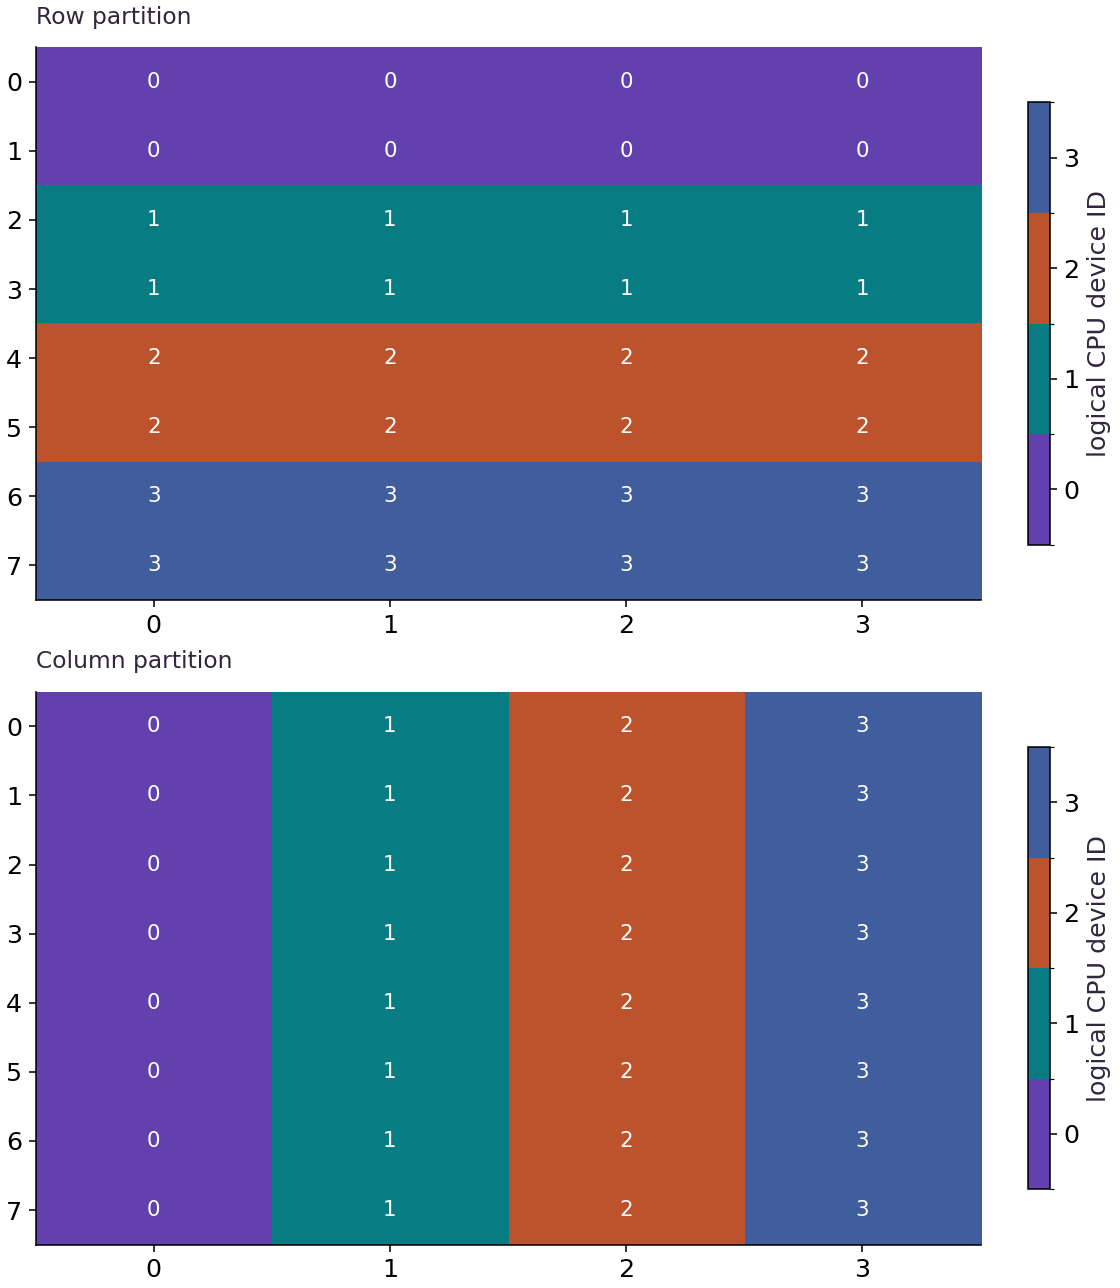

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Both panels represent the same global array with shape $(8,4)$. Each cell’s number and color identify its owning logical device, not the array value stored there. Device colors are categorical and do not rank speed or capacity.

In the upper panel, each device owns two complete rows: device $0$ owns rows $0$ and $1$, for example. In the lower panel, each device owns one complete column across all eight rows. The horizontal bands become vertical bands when the partitioned axis changes.

### Connect it to the computation

Each device owns eight scalar entries in either layout, but their local shapes differ: $(2,4)$ for row partitioning and $(8,1)$ for column partitioning. Equal local element counts do not mean that the same operations will have the same communication needs.

For example, a whole row is locally available in the upper layout but split across devices in the lower one. A row-wise reduction therefore has different placement implications. The figure establishes ownership only; communication volume and execution time are not measured, and these four logical devices share one CPU host.

## Reshard the same global values

Predict: Moving $x$ from row partitioning to column partitioning changes local shapes. Does it change the global values?

In [7]:
moved = jax.device_put(x, columns)
np.testing.assert_array_equal(np.asarray(moved), host)
assert all(s.data.shape == (8,1) for s in moved.addressable_shards)
print("Resharded values preserved")

Resharded values preserved


Expected: Global array unchanged; local shards now $(8,1)$.

Resharding changes ownership of values, not their mathematical identity.

## Reduce a dimension that is not partitioned

Predict: Sum each row. Predict the output shape and which mesh axis should partition it.

In [8]:
vector_rows = NamedSharding(mesh, P("data"))
per_row = jax.jit(lambda a:a.sum(axis=1), in_shardings=rows, out_shardings=vector_rows)(x)
np.testing.assert_array_equal(np.asarray(per_row), np.arange(6,119,16,dtype=np.float32))
assert all(s.data.shape == (2,) for s in per_row.addressable_shards)
print("Row sums:", np.asarray(per_row))

Row sums: [  6.  22.  38.  54.  70.  86. 102. 118.]


Expected: Row sums $[6,22,38,54,70,86,102,118]$; local shapes $(2,)$.

All four columns for a row are already local in row partitioning; this reduction does not mathematically require combining data-axis pieces.

## Your exercise

Compare row and column layouts of a $(12,8)$ array, and repair a ten-row mean with padding plus an explicit mask.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
other = np.arange(96,dtype=np.float32).reshape(12,8)
for spec, expected in [(rows,(3,8)),(columns,(12,2))]:
    placed = jax.device_put(other,spec)
    for shard in placed.addressable_shards:
        assert shard.data.shape == expected
        np.testing.assert_array_equal(np.asarray(shard.data),other[shard.index])

original = np.arange(40,dtype=np.float32).reshape(10,4)
try:
    jax.device_put(original, rows)
except ValueError:
    print("Expected indivisible batch")
else:
    raise AssertionError("Expected divisibility failure")
padded = jax.device_put(np.pad(original,((0,2),(0,0))),rows)
mask_sharding = NamedSharding(mesh,P("data"))
mask = jax.device_put(np.array([1]*10+[0]*2,dtype=np.float32),mask_sharding)
masked_mean = jax.jit(lambda a,m:(a*m[:,None]).sum(axis=0)/m.sum(),in_shardings=(rows,mask_sharding),out_shardings=replicated)(padded,mask)
np.testing.assert_allclose(np.asarray(masked_mean),original.mean(axis=0),rtol=1e-6)
assert not np.allclose(np.asarray(padded.mean(axis=0)), original.mean(axis=0))

Expected indivisible batch


## Change both dimensions · Challenge

Use a $(12,8)$ array. Verify row and column layouts and predict every local shape.

Hint: Four devices divide twelve rows or eight columns.

In [11]:
# Write your attempt here.

## Reference reasoning

The row layout owns three complete feature vectors per device; the column layout owns two features for every observation.

In [12]:
other = np.arange(96,dtype=np.float32).reshape(12,8)
for spec, expected in [(rows,(3,8)),(columns,(12,2))]:
    placed = jax.device_put(other,spec)
    for shard in placed.addressable_shards:
        assert shard.data.shape == expected
        np.testing.assert_array_equal(np.asarray(shard.data),other[shard.index])

## Pad an uneven batch without corrupting its mean · Challenge

Ten observations cannot be row-partitioned over four devices. Pad to twelve and use a mask to recover the true column mean. Demonstrate the wrong unmasked mean.

Hint: The divisor is the sum of the mask, not padded length.

In [13]:
# Write your attempt here.

## Reference reasoning

Padding repairs the shape but adds artificial rows. The mask keeps them out of both numerator and denominator. Checking only divisibility would miss this statistical error.

In [14]:
original = np.arange(40,dtype=np.float32).reshape(10,4)
try:
    jax.device_put(original, rows)
except ValueError:
    print("Expected indivisible batch")
else:
    raise AssertionError("Expected divisibility failure")
padded = jax.device_put(np.pad(original,((0,2),(0,0))),rows)
mask_sharding = NamedSharding(mesh,P("data"))
mask = jax.device_put(np.array([1]*10+[0]*2,dtype=np.float32),mask_sharding)
masked_mean = jax.jit(lambda a,m:(a*m[:,None]).sum(axis=0)/m.sum(),in_shardings=(rows,mask_sharding),out_shardings=replicated)(padded,mask)
np.testing.assert_allclose(np.asarray(masked_mean),original.mean(axis=0),rtol=1e-6)
assert not np.allclose(np.asarray(padded.mean(axis=0)), original.mean(axis=0))

Expected indivisible batch


## Checkpoint

With row sharding, why does a global column sum need results from other devices?

1. Each device initially holds only some rows.
2. Every sum requires host Python.
3. Partitioning changes the mathematical definition of sum.

## Diagnose

Padding repairs the shape but adds artificial rows. The mask keeps them out of both numerator and denominator. Checking only divisibility would miss this statistical error.

## Evidence

Padding repairs the shape but adds artificial rows. The mask keeps them out of both numerator and denominator. Checking only divisibility would miss this statistical error.

## Carry forward

- Read the mapping from left to right
- Inspect indices rather than guessing ordering
- A reduction has a communication requirement
- Choose placement for the operation you will perform

## Primary references

- [JAX CPU device configuration (set before initialization)](https://docs.jax.dev/en/latest/config_options.html#num-cpu-devices)
- [Distributed arrays and automatic parallelization](https://docs.jax.dev/en/latest/201/sharding.html)